# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: 
- _Student No._: 20XX-XXXXX
- _Section_: THR-TX-X

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

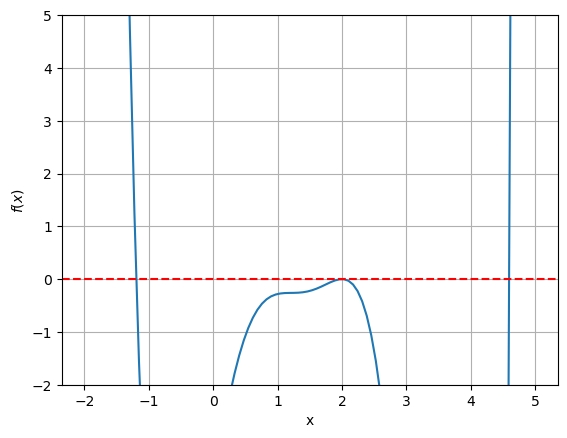

In [2]:
def f(x):
    return -(x**5) + 4*(x**4) - 4*(x**3) + (x**2)*np.exp(x) - 2*(x**2) - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

points = 100
xs = np.linspace(-2, 5, points, endpoint = True)
fxs = f(xs)

plt.plot(xs, fxs)
plt.ylim(-2, 5)
#plt.xlim(0,3)
plt.axhline(0, color="red", ls='--')
plt.xlabel("x")
plt.ylabel(r"$f(x)$")
plt.grid()
plt.savefig("fx.png")
plt.show()

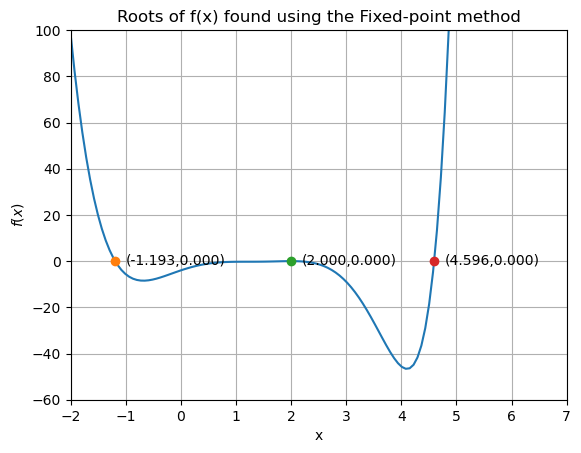

Actual values from Fixed-point method:
Root 1: -1.192685765190788
Root 2: 2
Root 3: 4.595863504338853


In [3]:
# Rewrite the function as g(x) s.t. x = g(x):

# We can guess where the roots are at from the graph. Massaging the equation gives us two ways to rewrite f(x).
def g_0(x):
    return np.cbrt(np.exp(x) - 2)

def g_1(x):
    return 2 # case when (x-2)^2 isn't 0 and the other term is!

def g_2(x):
    return np.log(x**3+2)


    
# Fixed-point method
def fixedPoint(func, x_old, k_max = 200, tol = 1.e-8): # k_max is how many steps we want to try
    history = [x_old] # storing iterations to plot convergence
    for k in range (1, k_max):
        # since the function is rewritten such that the roots are fixed-points, we grab a new x from the function
        x_new = func(x_old)

        # store every iteration so that we can plot the convergence
        history.append(x_new) 
        # and then we test how close they are
        x_diff = x_new-x_old

        # if they're really close such that its less than the tolerance, we end and this is now the root.
        if abs(x_diff/x_new) < tol:
            break

        # if it isn't, let the new x be the new guessing spot, if it converges, the x_old and x_new should converge, giving us the root.
        x_old = x_new

    else:
        # if it diverges, return None
        x_new = None

    return x_new, history

roots_fixed_point = []
convergence_curves_fixed_point = []        # (label, iterates, root) for the fixed-point runs
test_ranges = ([g_0, -1.5], [g_1, 2], [g_2, 4.5])

for func, x0 in test_ranges:
    root, hist = fixedPoint(func, x0)
    roots_fixed_point.append(root)
    convergence_curves_fixed_point.append((f"Fixed-point, $x_0$ = {x0}", hist, root))


plt.plot(xs, fxs)
for i in roots_fixed_point:
    plt.plot(i, f(i), 'o')
    plt.text(i+0.2, f(i), f'({i:.3f},{abs(f(i)):.3f})', verticalalignment="center")
plt.ylim(-60, 100)
plt.xlim(-2, 7)
plt.xlabel("x")
plt.ylabel(r"$f(x)$")
plt.grid()
plt.title('Roots of f(x) found using the Fixed-point method')
plt.savefig("fixedpoint.png")
plt.show()

print("Actual values from Fixed-point method:")
for i in range(len(roots_fixed_point)):
    print(f"Root {i+1}: {roots_fixed_point[i]}")

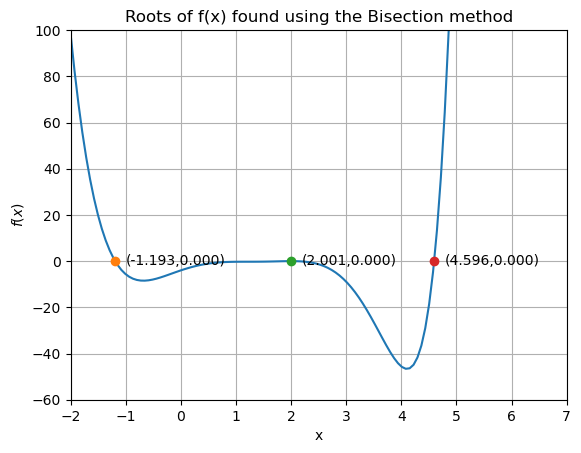

Actual values from Bisection method:
Root 1: -1.1926857605576515
Root 2: 2.0009999847412105
Root 3: 4.595863556861877


In [4]:
# Bisection method
def bisection(func, x_0, x_1, k_max=200, tol=1.e-8):
    func_0 = func(x_0)
    history = [(x_0 + x_1) / 2]                # first midpoint estimate, for the convergence plot
    for k in range(1, k_max):

        # bisect and then test it against the function
        x_2 = (x_0 + x_1) / 2
        func_2 = func(x_2)

        # if their products are less than 0, that means one of them is negative
        if func_0 * func_2 < 0:
            x_1 = x_2
        else:
            x_0, func_0 = x_2, func_2

        # bisect once more
        x_2_new = (x_0 + x_1) / 2
        history.append(x_2_new)                # store every estimate
        x_diff = abs(x_2_new - x_2)

        # if the relative difference between x2 new and x2 is less than the tolerance, break, its the root
        if abs(x_diff / x_2_new) < tol:
            break

    else:
        x_2_new = None

    return x_2_new, history


roots_bisection = []
convergence_curves_bisection = []
test_ranges_bisection = ([-1.5, -0.5], [1.999, 2.001], [4.5, 4.7])

for a, b in test_ranges_bisection:
    root, hist = bisection(f, a, b)
    roots_bisection.append(root)
    convergence_curves_bisection.append((f"Bisection, $[a,b]$ = [{a}, {b}]", hist, root))


plt.plot(xs, fxs)
for i in roots_bisection:
    plt.plot(i, f(i), 'o')
    plt.text(i+0.2, f(i), f'({i:.3f},{abs(f(i)):.3f})', verticalalignment="center")
plt.ylim(-60, 100)
plt.xlim(-2, 7)
plt.xlabel("x")
plt.ylabel(r"$f(x)$")
plt.grid()
plt.title('Roots of f(x) found using the Bisection method')
plt.savefig('bisection.png')
plt.show()

print("Actual values from Bisection method:")
for i in range(len(roots_bisection)):
    print(f"Root {i+1}: {roots_bisection[i]}")

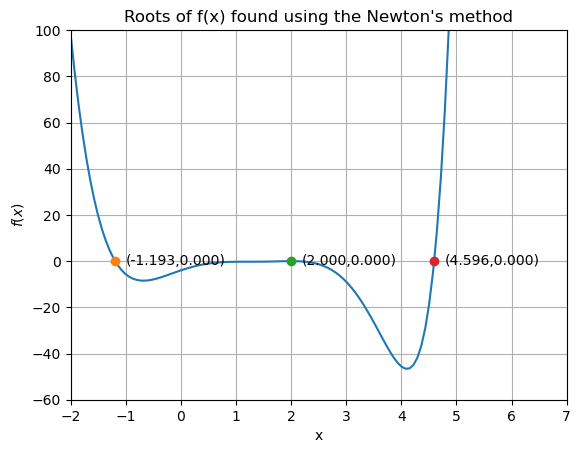

Actual values from Newton's method:
Root 1: -1.1926857650225988
Root 2: 2.000000052029864
Root 3: 4.595863564922456


In [5]:
# Newton's method

# we have to define the derivative of our function
def df(x):
    return -5*(x**4) + 16*(x**3) - 12*(x**2) + (x**2 - 2*x) * np.exp(x) - 4*x + 8

def newton(func, dfunc, x_old, k_max = 200, tol = 1e-8):
    history = [x_old]                          # store the initial guess too
    for k in range(1, k_max):
        # rise divided by slope is run, so we're getting x_new from subtracting horizontally from x_old, hopefully converging to 0
        x_new = x_old - func(x_old) / dfunc(x_old)
        history.append(x_new)                  # store every iterate

        # if the relative difference between x_new and x_old is less than tolerance, end the loop and lfg
        if abs((x_new - x_old) / x_new) < tol:
            break
        x_old = x_new
    else:
        x_new = None
    return x_new, history


roots_newton = []
convergence_curves_newton = []
test_ranges_newton = [-1, 2.01, 4.75]

for x0 in test_ranges_newton:
    root, hist = newton(f, df, x0)
    roots_newton.append(root)
    convergence_curves_newton.append((f"Newton, $x_0$ = {x0}", hist, root))


plt.plot(xs, fxs)
for i in roots_newton:
    plt.plot(i, f(i), 'o')
    plt.text(i+0.2, f(i), f'({i:.3f},{abs(f(i)):.3f})', verticalalignment="center")
plt.ylim(-60, 100)
plt.xlim(-2, 7)
plt.xlabel("x")
plt.ylabel(r"$f(x)$")
plt.grid()
plt.title("Roots of f(x) found using the Newton's method")
plt.savefig("newton.png")
plt.show()

print("Actual values from Newton's method:")
for i in range(len(roots_newton)):
    print(f"Root {i+1}: {roots_newton[i]}")

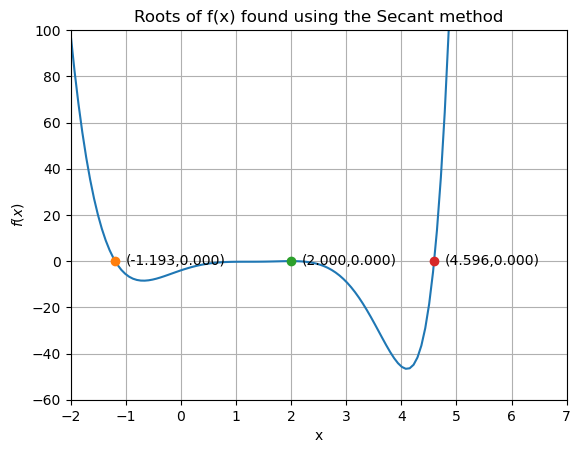

Actual values from Secant method:
Root 1: -1.1926857650225986
Root 2: 2.0000000565546494
Root 3: 4.595863564922455


In [6]:
# Secant method
def secant(func, x_0, x_1, k_max = 200, tol = 1.e-8):
    history = [x_0, x_1]                       # both initial guesses, for the convergence plot
    f_0 = func(x_0)
    for k in range(1, k_max):
        f_1 = func(x_1)
        ratio = (x_1 - x_0) / (f_1 - f_0)
        x_2 = x_1 - f_1 * ratio
        history.append(x_2)                    # store every iterate

        x_diff = abs(x_2 - x_1)
        x_0, x_1 = x_1, x_2
        f_0 = f_1

        if abs(x_diff / x_2) < tol:
            break

    else:
        x_2 = None

    return x_2, history


roots_secant = []
convergence_curves_secant = [] 
test_ranges_secant = ([-1.2, -0.5], [1.5, 3], [4.5, 4.7])

for a, b in test_ranges_secant:
    root, hist = secant(f, a, b)
    roots_secant.append(root)
    convergence_curves_secant.append((f"Secant, $x_0, x_1$ = [{a}, {b}]", hist, root))

plt.plot(xs, fxs)
for i in roots_secant:
    plt.plot(i, f(i), 'o')
    plt.text(i+0.2, f(i), f'({i:.3f},{abs(f(i)):.3f})', verticalalignment="center")
plt.ylim(-60, 100)
plt.xlim(-2, 7)
plt.xlabel("x")
plt.ylabel(r"$f(x)$")
plt.grid()
plt.title("Roots of f(x) found using the Secant method")
plt.savefig("secant.png")
plt.show()

print("Actual values from Secant method:")
for i in range(len(roots_secant)):
    print(f"Root {i+1}: {roots_secant[i]}")

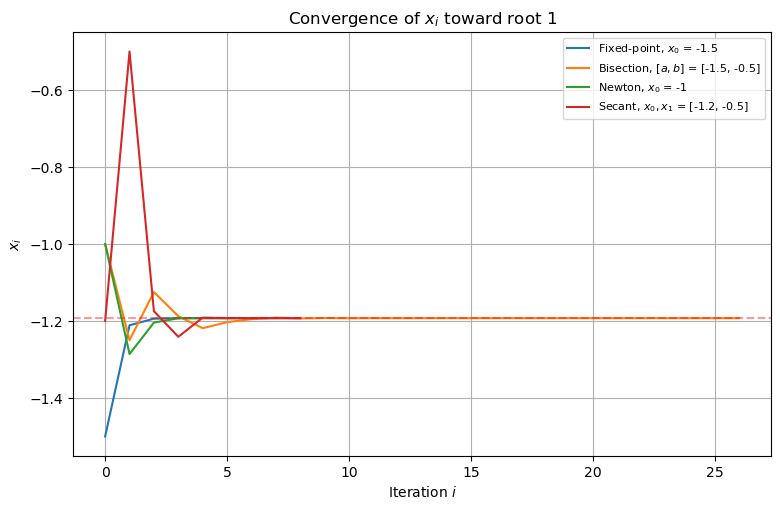

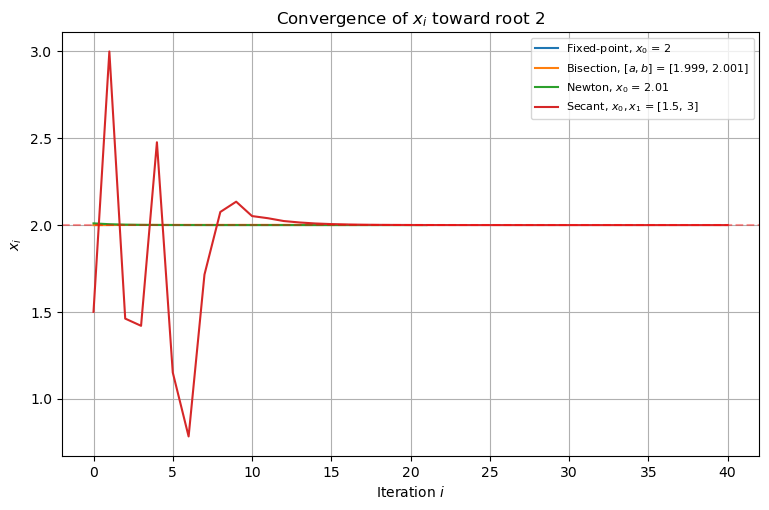

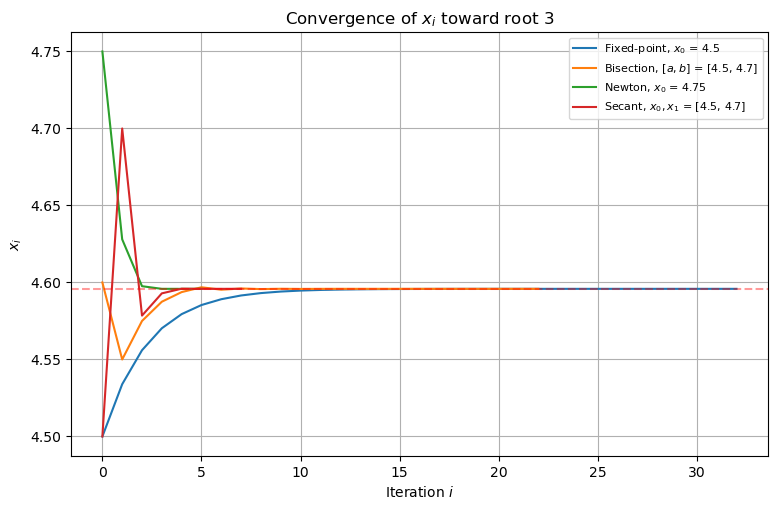

In [9]:
# Convergence plots:
methods = [convergence_curves_fixed_point,
           convergence_curves_bisection,
           convergence_curves_newton,
           convergence_curves_secant]
n_roots = 3
for j in range(n_roots):
    plt.figure(figsize=(9, 5.5))

    for curves in methods:
        label, hist, root = curves[j]
        hist = np.array(hist, dtype=float)
        line, = plt.plot(np.arange(len(hist)), hist, '-', ms=4, label=label)
            
    plt.axhline(root, color="red", ls='--', alpha=0.4)
    plt.xlabel("Iteration $i$")
    plt.ylabel(r"$x_i$")
    plt.title(f"Convergence of $x_i$ toward root {j+1}")
    plt.grid()
    plt.legend(fontsize=8)
    plt.savefig(f"convergence_{j}.png")
    plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

Making use of four different methods to find the roots. It is essentially trying to converge the difference between the new x and old x to 0 to find the root, so we make use of loops. 